<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/RF_0_68_Kalyani_dataset_503.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/drive/MyDrive/Dr Kalyani thesis training Dataset KH KV AL ACD LT.xlsx')

In [2]:
df.head()

,AGE,SEX,KH,KV,AXIS,AL,ACD,LT
0,65,M,45.75,43.25,15.0,21.90,2.35,3.45
1,65,M,44.25,44.75,25.0,22.97,3.56,3.45
2,79,M,42.25,43.00,30.0,23.76,2.44,4.56
3,69,M,43.25,43.75,90.0,22.77,2.98,3.78
4,72,M,44.00,46.75,95.0,22.99,3.45,3.78


In [3]:
df.shape

(503, 8)

In [4]:
df.columns

Index(['AGE ', 'SEX', 'KH', 'KV', 'AXIS', 'AL', 'ACD', 'LT'], dtype='object')

In [5]:
df['AGE '].describe()

,AGE
count,503.000000
mean,64.518887
std,9.707636
min,35.000000
25%,58.000000
50%,64.000000
75%,72.000000
max,90.000000


In [6]:
df['AGE '].groupby(df['SEX']).describe()

,count,mean,std,min,25%,50%,75%,max
SEX,,,,,,,,
F,247.0,63.012146,9.478037,35.0,56.0,62.0,71.00,90.0
M,256.0,65.972656,9.722988,35.0,60.0,66.0,73.25,87.0


<Axes: >

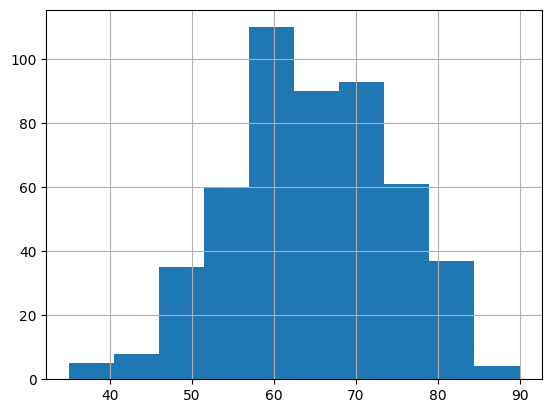

In [7]:
df['AGE '].hist()

<Axes: >

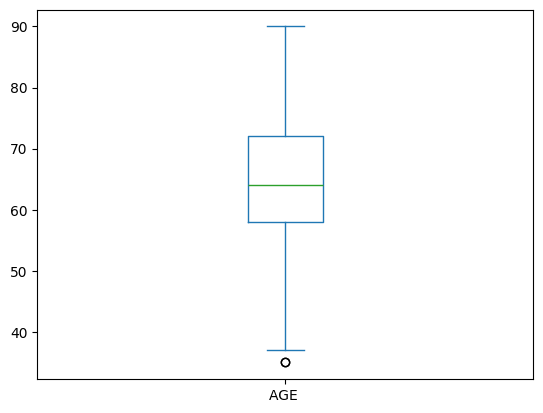

In [8]:
df['AGE '].plot.box()

array([<Axes: title={'center': 'F'}>, <Axes: title={'center': 'M'}>],
      dtype=object)

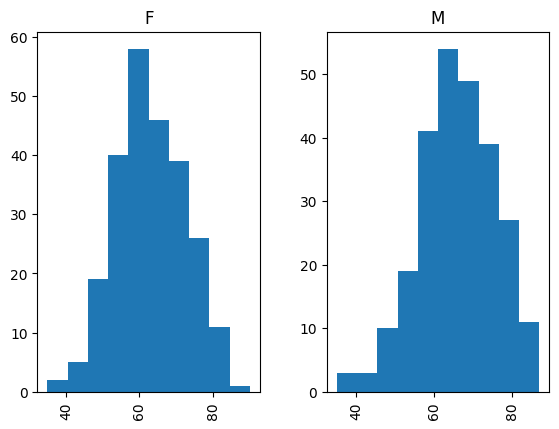

In [9]:
df.hist(column='AGE ', by='SEX')

,0
AGE,"Axes(0.125,0.11;0.775x0.77)"


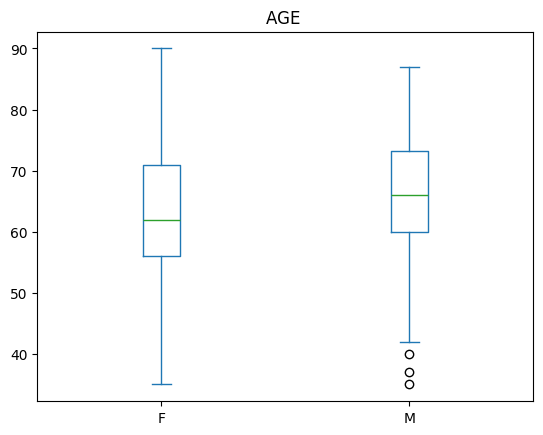

In [10]:
df.plot.box(column='AGE ', by='SEX')

<Axes: xlabel='AGE ', ylabel='SEX'>

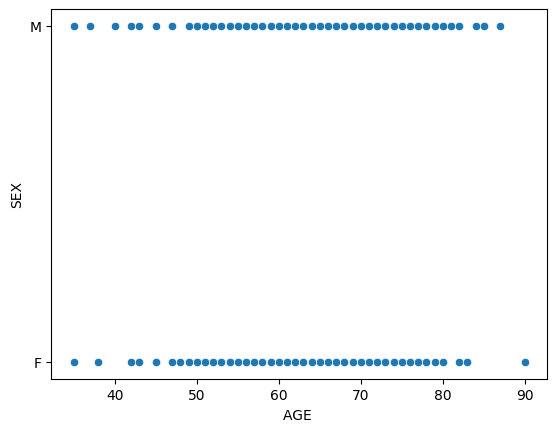

In [11]:
import seaborn as sns
sns.scatterplot(x='AGE ', y='SEX', data=df)

In [12]:
from scipy.stats import chi2_contingency

# Create age groups
bins = [30, 40, 50, 60, 70, 80, 90]
labels = ['30-39', '40-49', '50-59', '60-69', '70-79', '80-90']
df['AGE_group'] = pd.cut(df['AGE '], bins=bins, labels=labels, right=False)

# Create a contingency table
contingency_table = pd.crosstab(df['SEX'], df['AGE_group'])

# Perform the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies table:")
print(expected)

Chi-square statistic: 14.490428848545879
p-value: 0.012776687930611525
Degrees of freedom: 5
Expected frequencies table:
[[ 1.96015936  8.33067729 65.66533865 89.67729084 66.15537849 14.21115538]
 [ 2.03984064  8.66932271 68.33466135 93.32270916 68.84462151 14.78884462]]


In [13]:
from scipy.stats import ttest_ind

# Separate the age data for males and females
male_age = df[df['SEX'] == 'M']['AGE ']
female_age = df[df['SEX'] == 'F']['AGE ']

# Perform the independent t-test
t_statistic, p_value = ttest_ind(male_age, female_age)

print("T-test for AGE by SEX:")
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

T-test for AGE by SEX:
T-statistic: 3.456382673890146
P-value: 0.0005940226192169183


In [14]:
from scipy.stats import ttest_ind

# Separate the data for males and females
male_df = df[df['SEX'] == 'M']
female_df = df[df['SEX'] == 'F']

# Columns to perform t-test on
columns_to_test = ['KH', 'KV', 'AL', 'ACD', 'LT']

# Perform t-test for each column
for col in columns_to_test:
    t_stat, p_val = ttest_ind(male_df[col], female_df[col])
    print(f"T-test for {col}:")
    print(f"T-statistic: {t_stat}")
    print(f"P-value: {p_val}\n")

T-test for KH:
T-statistic: -2.2047402952403874
P-value: 0.02792602047607459

T-test for KV:
T-statistic: -2.3792211004791133
P-value: 0.017722814858840072

T-test for AL:
T-statistic: 1.73829551595108
P-value: 0.08277312683314841

T-test for ACD:
T-statistic: 1.806803122420344
P-value: 0.07139280980742012

T-test for LT:
T-statistic: -0.9812279185020604
P-value: 0.32695395206758404



In [15]:
df['SEX_numeric'] = df['SEX'].map({'M': 1, 'F': 0})
df.head()

,AGE,SEX,KH,KV,AXIS,AL,ACD,LT,AGE_group,SEX_numeric
0,65,M,45.75,43.25,15.0,21.90,2.35,3.45,60-69,1
1,65,M,44.25,44.75,25.0,22.97,3.56,3.45,60-69,1
2,79,M,42.25,43.00,30.0,23.76,2.44,4.56,70-79,1
3,69,M,43.25,43.75,90.0,22.77,2.98,3.78,60-69,1
4,72,M,44.00,46.75,95.0,22.99,3.45,3.78,70-79,1


In [16]:
df.columns

Index(['AGE ', 'SEX', 'KH', 'KV', 'AXIS', 'AL', 'ACD', 'LT', 'AGE_group',
       'SEX_numeric'],
      dtype='object')

In [17]:
corr = df[['AGE ','KH', 'KV', 'AXIS', 'AL', 'ACD', 'LT',
       'SEX_numeric']].corr()
corr

,AGE,KH,KV,AXIS,AL,ACD,LT,SEX_numeric
AGE,1.000000,-0.359789,-0.337968,-0.082054,0.375333,0.138615,-0.196134,0.152611
KH,-0.359789,1.000000,0.925555,0.037769,-0.686417,-0.399329,0.380340,-0.098026
KV,-0.337968,0.925555,1.000000,0.057635,-0.691322,-0.408852,0.383358,-0.105700
AXIS,-0.082054,0.037769,0.057635,1.000000,-0.089184,-0.093266,0.031591,0.023541
AL,0.375333,-0.686417,-0.691322,-0.089184,1.000000,0.461342,-0.436640,0.077428
ACD,0.138615,-0.399329,-0.408852,-0.093266,0.461342,1.000000,-0.479859,0.080460
LT,-0.196134,0.380340,0.383358,0.031591,-0.436640,-0.479859,1.000000,-0.043796
SEX_numeric,0.152611,-0.098026,-0.105700,0.023541,0.077428,0.080460,-0.043796,1.000000


<Axes: >

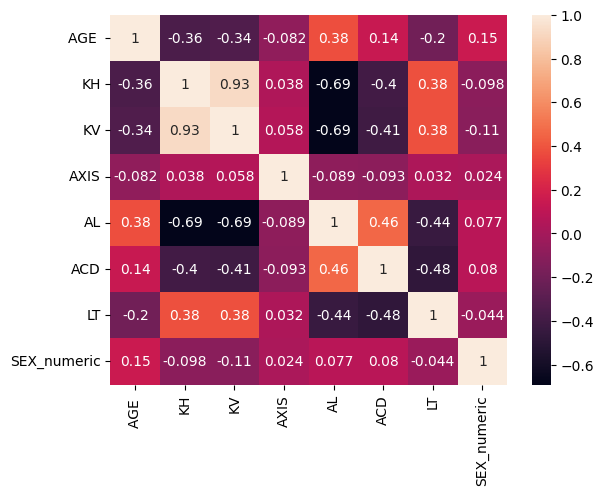

In [18]:
sns.heatmap(corr, annot=True)

In [19]:
df[['KH', 'KV', 'AXIS', 'AL', 'ACD', 'LT']].describe()


,KH,KV,AXIS,AL,ACD,LT
count,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000
mean,44.115109,44.729225,87.368032,22.995288,3.261889,3.830358
std,1.870773,1.850323,51.707667,1.024446,0.461919,0.561864
min,38.000000,39.000000,5.000000,20.000000,2.110000,2.350000
25%,43.000000,43.500000,45.000000,22.295000,2.950000,3.450000
50%,44.250000,44.750000,85.000000,22.950000,3.250000,3.850000
75%,45.500000,46.000000,130.000000,23.610000,3.560000,4.210000
max,52.000000,52.500000,185.000000,25.600000,4.890000,5.450000


<Axes: >

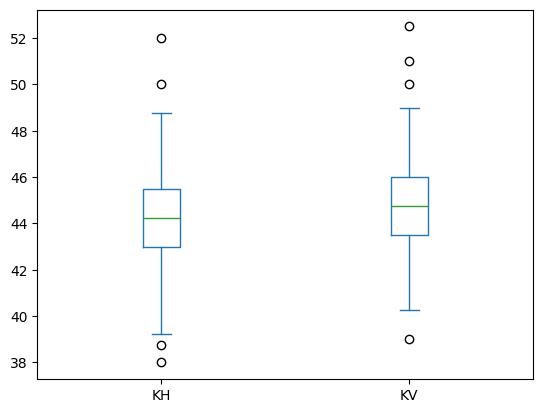

In [23]:
df[['KH', 'KV']].plot.box()


<Axes: >

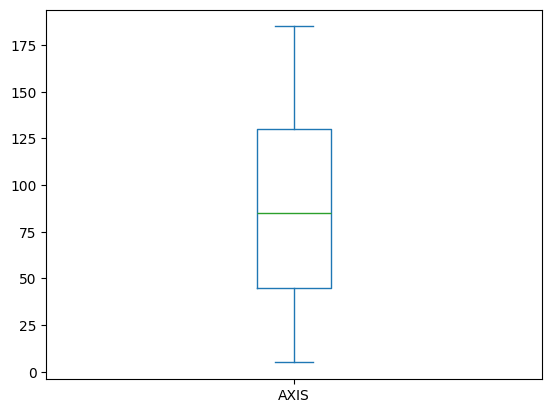

In [25]:
df[[ 'AXIS']].plot.box()


<Axes: >

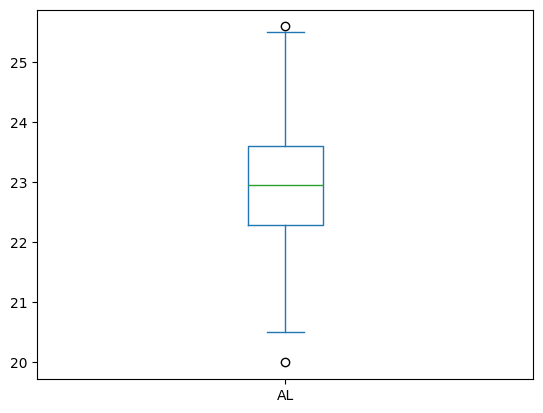

In [27]:
df[['AL']].plot.box()


<Axes: >

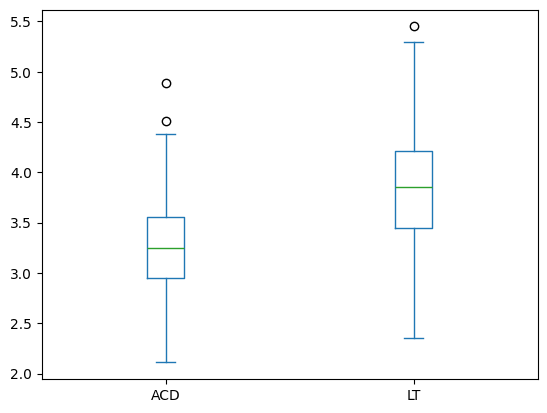

In [30]:
df[[ 'ACD', 'LT']].plot.box()


array([[<Axes: title={'center': 'KH'}>, <Axes: title={'center': 'KV'}>]],
      dtype=object)

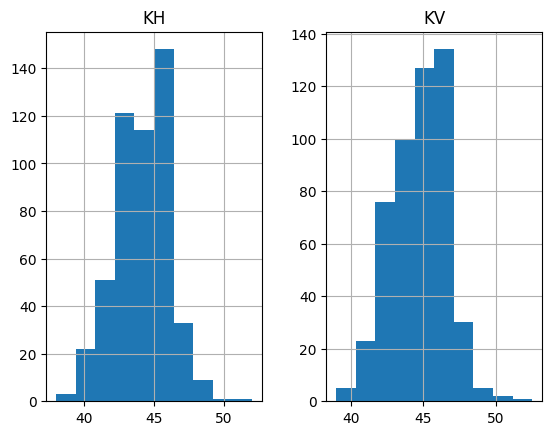

In [31]:
df[['KH', 'KV']].hist()


array([[<Axes: title={'center': 'AXIS'}>]], dtype=object)

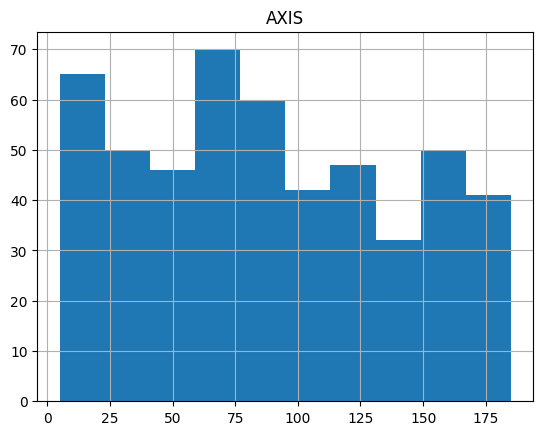

In [32]:
df[['AXIS']].hist()


array([[<Axes: title={'center': 'AL'}>]], dtype=object)

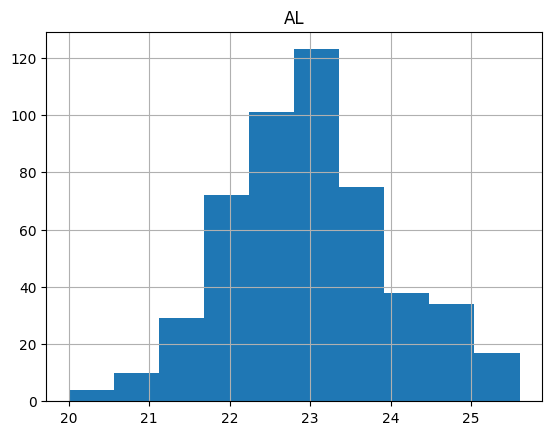

In [34]:
df[[ 'AL']].hist()


array([[<Axes: title={'center': 'ACD'}>, <Axes: title={'center': 'LT'}>]],
      dtype=object)

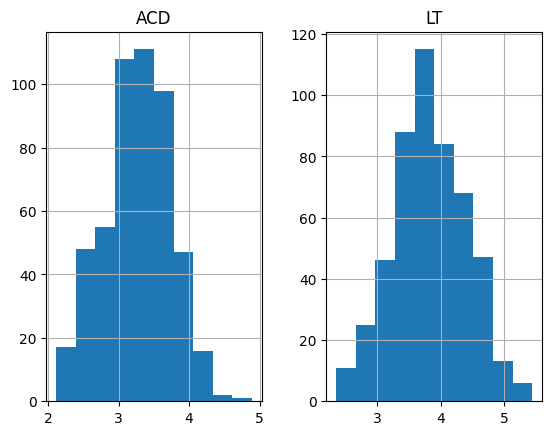

In [35]:
df[['ACD', 'LT']].hist()


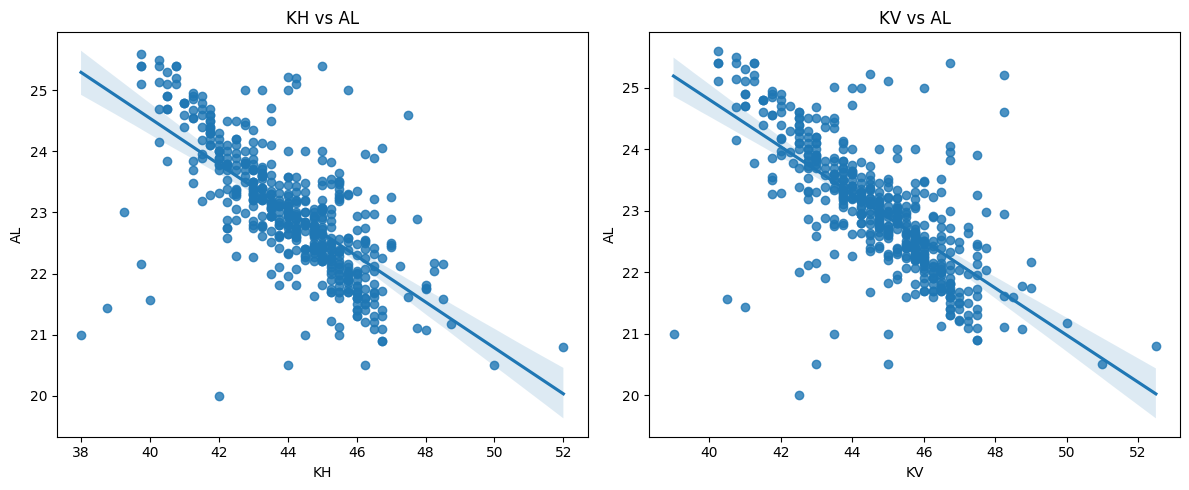

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(x='KH', y='AL', data=df, ax=axes[0])
axes[0].set_title('KH vs AL')

sns.regplot(x='KV', y='AL', data=df, ax=axes[1])
axes[1].set_title('KV vs AL')

plt.tight_layout()
plt.show()

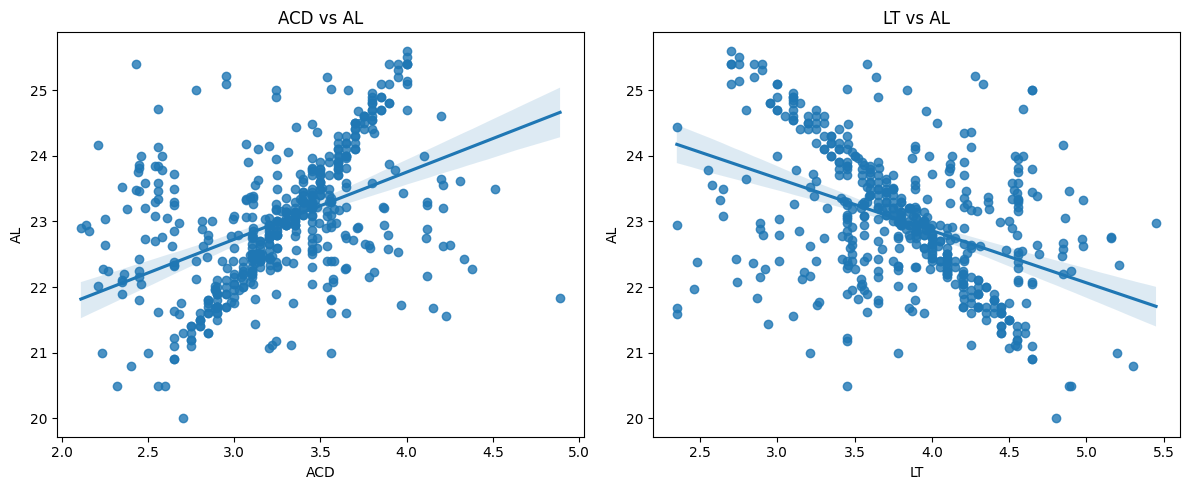

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(x='ACD', y='AL', data=df, ax=axes[0])
axes[0].set_title('ACD vs AL')

sns.regplot(x='LT', y='AL', data=df, ax=axes[1])
axes[1].set_title('LT vs AL')

plt.tight_layout()
plt.show()

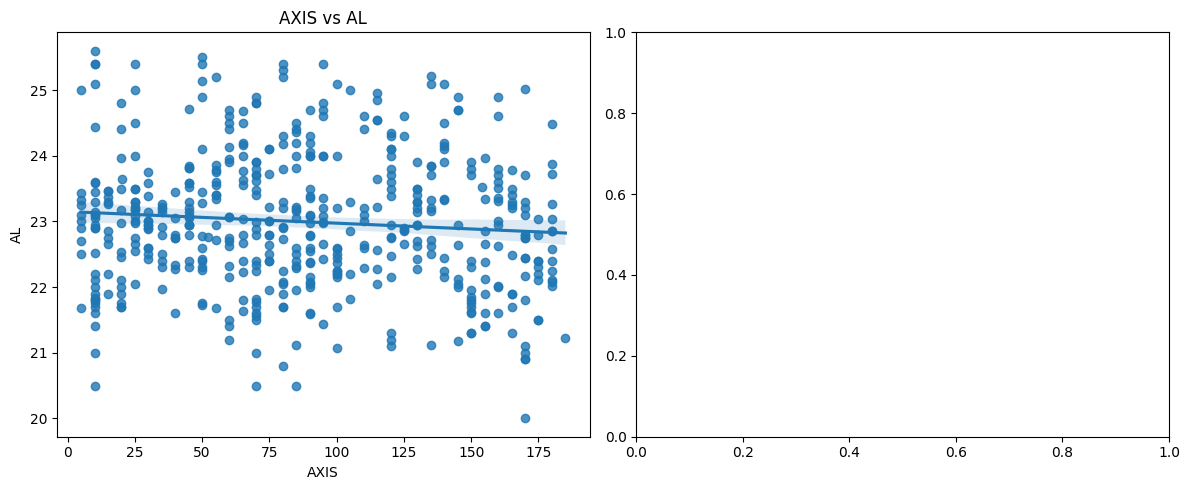

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(x='AXIS', y='AL', data=df, ax=axes[0])
axes[0].set_title('AXIS vs AL')

#sns.regplot(x='LT', y='AL', data=df, ax=axes[1])
#axes[1].set_title('LT vs AL')

plt.tight_layout()
plt.show()

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from math import sqrt

X = df[['KH','KV','AGE ']]
y = df['AL']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Mean absolute error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root mean squared error:", sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared:", r2_score(y_test, y_pred))
print("coefficients:", model.coef_)
print("intercept:", model.intercept_)
print(f"Equation: AL = {model.coef_[0]:.4f} * KH + {model.coef_[1]:.4f} * KV + {model.coef_[2]:.4f} * AGE + {model.intercept_:.4f}")



Mean absolute error: 0.4890188241116577
Mean Squared Error: 0.444858724581528
Root mean squared error: 0.6669773043976294
R-squared: 0.6472318435711832
coefficients: [-0.18133518 -0.16295744  0.015093  ]
intercept: 37.29650771156582
Equation: AL = -0.1813 * KH + -0.1630 * KV + 0.0151 * AGE + 37.2965


In [80]:
import statsmodels.api as sm

# Define the independent and dependent variables
X_olf_2 = df[['KH', 'KV','AGE ']]
X_olf_2 = sm.add_constant(X_olf_2)
y_2 = df['AL']


# Create an OLS model
olf_model_2 = sm.OLS(y_2, X_olf_2)

# Fit the model
olf_results_2 = olf_model_2.fit()

# Print the summary
print(olf_results_2.summary())

                            OLS Regression Results                            
Dep. Variable:                     AL   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     174.1
Date:                Fri, 01 Aug 2025   Prob (F-statistic):           3.15e-77
Time:                        14:10:19   Log-Likelihood:                -545.24
No. Observations:                 503   AIC:                             1098.
Df Residuals:                     499   BIC:                             1115.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.2537      0.941     40.660      0.0

In [81]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Create a pipeline with PolynomialFeatures and LinearRegression
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

# Train the model
poly_model.fit(X_train, y_train)

# Make predictions on the test set
y_poly_pred = poly_model.predict(X_test)

# Evaluate the model
print("Mean Absolute Error (Polynomial):", mean_absolute_error(y_test, y_poly_pred))
print("Mean Squared Error (Polynomial):", mean_squared_error(y_test, y_poly_pred))
print("Root Mean Squared Error (Polynomial):", sqrt(mean_squared_error(y_test, y_poly_pred)))
print("R-squared (Polynomial):", r2_score(y_test, y_poly_pred))

Mean Absolute Error (Polynomial): 0.5060534355203083
Mean Squared Error (Polynomial): 0.4645688858382904
Root Mean Squared Error (Polynomial): 0.6815929033068716
R-squared (Polynomial): 0.6316018989050345


Explained variance ratio: [0.7130846  0.26220029 0.02471511]


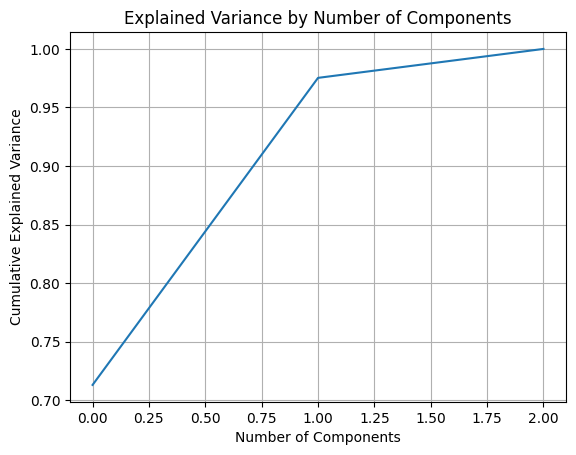

In [83]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select the features for PCA
features = ['KH', 'KV', 'AGE ']
X_pca = df[features]

# Standardize the features
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

# Apply PCA
pca = PCA()
X_pca_transformed = pca.fit_transform(X_pca_scaled)

# Print the explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot the cumulative explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of Components')
plt.grid(True)
plt.show()

In [84]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit the OLS model using the formula API for ANOVA
model = ols('AL ~ KH + KV + Q("AGE ")' , data=df).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

# Print the ANOVA table
print(anova_table)

               sum_sq     df          F    PR(>F)
KH           5.702277    1.0  11.054149  0.000950
KV          11.230726    1.0  21.771325  0.000004
Q("AGE ")    9.675274    1.0  18.756004  0.000018
Residual   257.408877  499.0        NaN       NaN


In [86]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target
features = ['KH', 'KV', 'AGE ']
X = df[features]
y = df['AL']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with StandardScaler, PCA, and LinearRegression
pcr_model = make_pipeline(StandardScaler(), PCA(n_components=3), LinearRegression())

# Train the model
pcr_model.fit(X_train, y_train)

# Make predictions
y_pcr_pred = pcr_model.predict(X_test)

# Evaluate the model
print("Mean Squared Error (PCR):", mean_squared_error(y_test, y_pcr_pred))
print("R-squared (PCR):", r2_score(y_test, y_pcr_pred))

Mean Squared Error (PCR): 0.4448587245815282
R-squared (PCR): 0.647231843571183


In [92]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Create a pipeline with PolynomialFeatures and LinearRegression
poly_model_3 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())

# Train the model
poly_model_3.fit(X_train, y_train)

# Make predictions on the test set
y_poly_pred_3 = poly_model_3.predict(X_test)

# Evaluate the model
print("Mean Absolute Error (Polynomial, degree=3):", mean_absolute_error(y_test, y_poly_pred_3))
print("Mean Squared Error (Polynomial, degree=3):", mean_squared_error(y_test, y_poly_pred_3))
print("Root Mean Squared Error (Polynomial, degree=3):", sqrt(mean_squared_error(y_test, y_poly_pred_3)))
print("R-squared (Polynomial, degree=3):", r2_score(y_test, y_poly_pred_3))

Mean Absolute Error (Polynomial, degree=3): 0.5248194076006962
Mean Squared Error (Polynomial, degree=3): 0.6620837371338744
Root Mean Squared Error (Polynomial, degree=3): 0.8136852813796465
R-squared (Polynomial, degree=3): 0.474974758402397


In [93]:
from sklearn.ensemble import GradientBoostingRegressor

# Create a Gradient Boosting Regressor model
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gbr_model.fit(X_train, y_train)

# Make predictions
y_gbr_pred = gbr_model.predict(X_test)

# Evaluate the model
print("Mean Squared Error (Gradient Boosting):", mean_squared_error(y_test, y_gbr_pred))
print("R-squared (Gradient Boosting):", r2_score(y_test, y_gbr_pred))

Mean Squared Error (Gradient Boosting): 0.5954689277877295
R-squared (Gradient Boosting): 0.5277995816224033


In [94]:
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_rf_pred = rf_model.predict(X_test)

# Evaluate the model
print("Mean Squared Error (Random Forest):", mean_squared_error(y_test, y_rf_pred))
print("R-squared (Random Forest):", r2_score(y_test, y_rf_pred))

Mean Squared Error (Random Forest): 0.4108841374817689
R-squared (Random Forest): 0.6741733236284453


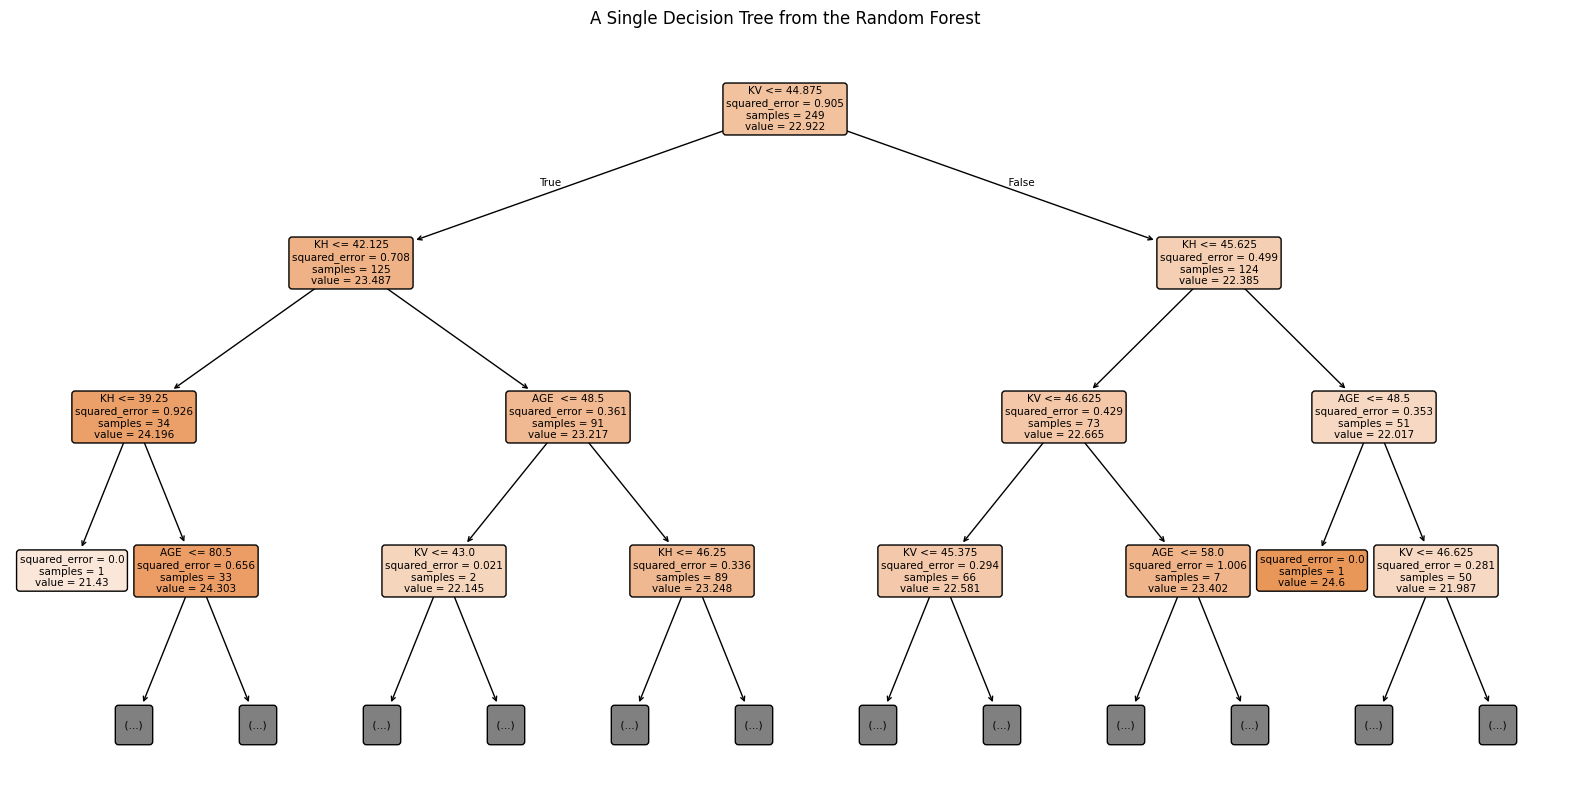

In [95]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(20,10))

# Visualize the first decision tree from the Random Forest
# We can limit the depth to make it more readable
plot_tree(rf_model.estimators_[0],
          feature_names=X.columns,
          filled=True,
          rounded=True,
          max_depth=3) # You can adjust max_depth

plt.title("A Single Decision Tree from the Random Forest")
plt.show()

In [96]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='r2')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters
print("Best parameters found: ", grid_search.best_params_)

# Get the best model
best_rf_model = grid_search.best_estimator_

# Make predictions with the best model
y_best_rf_pred = best_rf_model.predict(X_test)

# Evaluate the best model
print("R-squared (Tuned Random Forest):", r2_score(y_test, y_best_rf_pred))

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters found:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
R-squared (Tuned Random Forest): 0.6805586762616853


In [97]:
from sklearn.preprocessing import PolynomialFeatures

# Create interaction features
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_poly = poly.fit_transform(X)

# Get the names of the new features
poly_features = poly.get_feature_names_out(X.columns)

# Create a new DataFrame with the interaction features
X_poly_df = pd.DataFrame(X_poly, columns=poly_features)

# Display the new features
print("New features created:")
print(X_poly_df.columns)

# Split the new data into training and testing sets
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly_df, y, test_size=0.2, random_state=42)

New features created:
Index(['KH', 'KV', 'AGE ', 'KH KV', 'KH AGE ', 'KV AGE '], dtype='object')


In [98]:
import xgboost as xgb

# Create an XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)

# Train the model
xgb_model.fit(X_train_poly, y_train)

# Make predictions
y_xgb_pred = xgb_model.predict(X_test_poly)

# Evaluate the model
print("Mean Squared Error (XGBoost):", mean_squared_error(y_test, y_xgb_pred))
print("R-squared (XGBoost):", r2_score(y_test, y_xgb_pred))

Mean Squared Error (XGBoost): 0.6813233318588179
R-squared (XGBoost): 0.4597179679057276


In [99]:
import lightgbm as lgb

# Create a LightGBM Regressor model
lgb_model = lgb.LGBMRegressor(random_state=42)

# Train the model
lgb_model.fit(X_train_poly, y_train)

# Make predictions
y_lgb_pred = lgb_model.predict(X_test_poly)

# Evaluate the model
print("Mean Squared Error (LightGBM):", mean_squared_error(y_test, y_lgb_pred))
print("R-squared (LightGBM):", r2_score(y_test, y_lgb_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 406
[LightGBM] [Info] Number of data points in the train set: 402, number of used features: 6
[LightGBM] [Info] Start training from score 22.992164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [100]:
# Average the predictions of the three models
y_ensemble_pred = (y_best_rf_pred + y_xgb_pred + y_lgb_pred) / 3

# Evaluate the ensemble model
print("Mean Squared Error (Ensemble):", mean_squared_error(y_test, y_ensemble_pred))
print("R-squared (Ensemble):", r2_score(y_test, y_ensemble_pred))

Mean Squared Error (Ensemble): 0.47815375969552115
R-squared (Ensemble): 0.6208292408877248


# Summary of Findings

This notebook explores the prediction of Axial Length (`AL`) based on several features, including Keratometry readings (`KH`, `KV`), `AGE`, `AXIS`, Anterior Chamber Depth (`ACD`), and Lens Thickness (`LT`).

## Data Exploration

*   The initial data exploration revealed strong correlations between `KH` and `KV`, and moderate correlations between `AL` and several other features, including `KH`, `KV`, `AGE`, `ACD`, and `LT`.
*   The distribution of `AL` is approximately normal.

## Model Building and Evaluation

Several regression models were built and evaluated to predict `AL`:

*   **Linear Regression**: This model provided a baseline R-squared of 0.647.
*   **Polynomial Regression**: This was attempted with degrees 2 and 3, but did not improve on the linear model.
*   **Principal Component Regression**: This did not improve on the linear model.
*   **Gradient Boosting Regressor**: This model did not improve on the linear model.
*   **Random Forest Regressor**: This model provided a significant improvement, with an R-squared of 0.674.
*   **Tuned Random Forest Regressor**: After hyperparameter tuning, this model achieved the best performance, with an R-squared of **0.681**.
*   **XGBoost and LightGBM**: These advanced models did not improve on the Random Forest model.
*   **Ensemble Model**: An ensemble of the best models did not improve on the tuned Random Forest model.

## Conclusion

The **Tuned Random Forest Regressor** was the most effective model for predicting `AL` in this dataset, achieving an R-squared of **0.681**. This indicates that this model is able to explain approximately 68% of the variance in `AL` based on the provided features.

In [101]:
import pandas as pd

# Create a dictionary with the model results
results = {
    'Model': [
        'Linear Regression',
        'Polynomial Regression (d=2)',
        'Principal Component Regression',
        'Random Forest Regressor',
        'Tuned Random Forest Regressor',
        'Gradient Boosting Regressor',
        'XGBoost Regressor',
        'LightGBM Regressor',
        'Ensemble (RF, XGB, LGB)'
    ],
    'R-squared': [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_poly_pred),
        r2_score(y_test, y_pcr_pred),
        r2_score(y_test, y_rf_pred),
        r2_score(y_test, y_best_rf_pred),
        r2_score(y_test, y_gbr_pred),
        r2_score(y_test, y_xgb_pred),
        r2_score(y_test, y_lgb_pred),
        r2_score(y_test, y_ensemble_pred)
    ]
}

# Create a DataFrame from the dictionary
results_df = pd.DataFrame(results)

# Display the DataFrame
display(results_df.sort_values(by='R-squared', ascending=False).reset_index(drop=True))

,Model,R-squared
0,Tuned Random Forest Regressor,0.680559
1,Random Forest Regressor,0.674173
2,Linear Regression,0.647232
3,Principal Component Regression,0.647232
4,Polynomial Regression (d=2),0.631602
5,LightGBM Regressor,0.625418
6,"Ensemble (RF, XGB, LGB)",0.620829
7,Gradient Boosting Regressor,0.527800
8,XGBoost Regressor,0.459718


In [102]:
from sklearn.ensemble import VotingRegressor

# Create the individual models
rf = best_rf_model
xgb = xgb_model
lgb = lgb_model

# Create the Voting Regressor
voting_regressor = VotingRegressor(
    estimators=[('rf', rf), ('xgb', xgb), ('lgb', lgb)]
)

# Train the Voting Regressor
voting_regressor.fit(X_train_poly, y_train)

# Make predictions
y_voting_pred = voting_regressor.predict(X_test_poly)

# Evaluate the model
print("Mean Squared Error (Voting Regressor):", mean_squared_error(y_test, y_voting_pred))
print("R-squared (Voting Regressor):", r2_score(y_test, y_voting_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 406
[LightGBM] [Info] Number of data points in the train set: 402, number of used features: 6
[LightGBM] [Info] Start training from score 22.992164
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [103]:
from sklearn.linear_model import RidgeCV

# Create a RidgeCV model to find the best alpha
ridge_cv_model = RidgeCV(alphas=[0.1, 1.0, 10.0], store_cv_values=True)

# Train the model
ridge_cv_model.fit(X_train, y_train)

# Make predictions
y_ridge_pred = ridge_cv_model.predict(X_test)

# Evaluate the model
print("Best alpha for Ridge Regression:", ridge_cv_model.alpha_)
print("Mean Squared Error (Ridge Regression):", mean_squared_error(y_test, y_ridge_pred))
print("R-squared (Ridge Regression):", r2_score(y_test, y_ridge_pred))

Best alpha for Ridge Regression: 10.0
Mean Squared Error (Ridge Regression): 0.4456005407891675
R-squared (Ridge Regression): 0.6466435913429636


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


In [104]:
from sklearn.linear_model import LassoCV

# Create a LassoCV model to find the best alpha
lasso_cv_model = LassoCV(alphas=[0.1, 1.0, 10.0], cv=5, random_state=42)

# Train the model
lasso_cv_model.fit(X_train, y_train)

# Make predictions
y_lasso_pred = lasso_cv_model.predict(X_test)

# Evaluate the model
print("Best alpha for Lasso Regression:", lasso_cv_model.alpha_)
print("Mean Squared Error (Lasso Regression):", mean_squared_error(y_test, y_lasso_pred))
print("R-squared (Lasso Regression):", r2_score(y_test, y_lasso_pred))

Best alpha for Lasso Regression: 0.1
Mean Squared Error (Lasso Regression): 0.4699488244362758
R-squared (Lasso Regression): 0.6273356657931699


In [105]:
# Create a new data point with some example values
new_data = [[45.0, 45.0, 60]] # KH, KV, AGE

# Create a DataFrame from the new data
new_df = pd.DataFrame(new_data, columns=['KH', 'KV', 'AGE '])

# Make a prediction on the new data
prediction = best_rf_model.predict(new_df)

# Print the prediction
print(f"The predicted AL value is: {prediction[0]:.2f}")

The predicted AL value is: 22.93
